In [ ]:
OHE, temporais, BatchNorm, SMOTE + pesos ajustados e threshold tuning), mas traz data leakage

Epoch 1/60


<>:31: SyntaxWarning: invalid escape sequence '\+'
<>:31: SyntaxWarning: invalid escape sequence '\+'
/var/folders/cx/rl_qn7mn409324ckkc65lsnh0000gn/T/ipykernel_83025/1513056200.py:31: SyntaxWarning: invalid escape sequence '\+'
  meteo['dt_iso_clean'] = meteo['dt_iso'].str.replace(' \+0000 UTC', '', regex=True)
/opt/anaconda3/envs/lcd_scaa/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


973/973 - 2s - 2ms/step - accuracy: 0.6413 - loss: 0.8425 - val_accuracy: 0.7940 - val_loss: 0.5004
Epoch 2/60
973/973 - 1s - 809us/step - accuracy: 0.7015 - loss: 0.6953 - val_accuracy: 0.8017 - val_loss: 0.4656
Epoch 3/60
973/973 - 1s - 763us/step - accuracy: 0.7171 - loss: 0.6557 - val_accuracy: 0.8099 - val_loss: 0.4524
Epoch 4/60
973/973 - 1s - 761us/step - accuracy: 0.7254 - loss: 0.6357 - val_accuracy: 0.8094 - val_loss: 0.4738
Epoch 5/60
973/973 - 1s - 753us/step - accuracy: 0.7374 - loss: 0.6154 - val_accuracy: 0.8158 - val_loss: 0.4562
Epoch 6/60
973/973 - 1s - 752us/step - accuracy: 0.7423 - loss: 0.5999 - val_accuracy: 0.8108 - val_loss: 0.4759
Epoch 7/60
973/973 - 1s - 801us/step - accuracy: 0.7497 - loss: 0.5858 - val_accuracy: 0.8058 - val_loss: 0.4825
Epoch 8/60
973/973 - 1s - 752us/step - accuracy: 0.7527 - loss: 0.5741 - val_accuracy: 0.8081 - val_loss: 0.4653
Epoch 9/60
973/973 - 1s - 758us/step - accuracy: 0.7614 - loss: 0.5614 - val_accuracy: 0.8185 - val_loss: 0.4

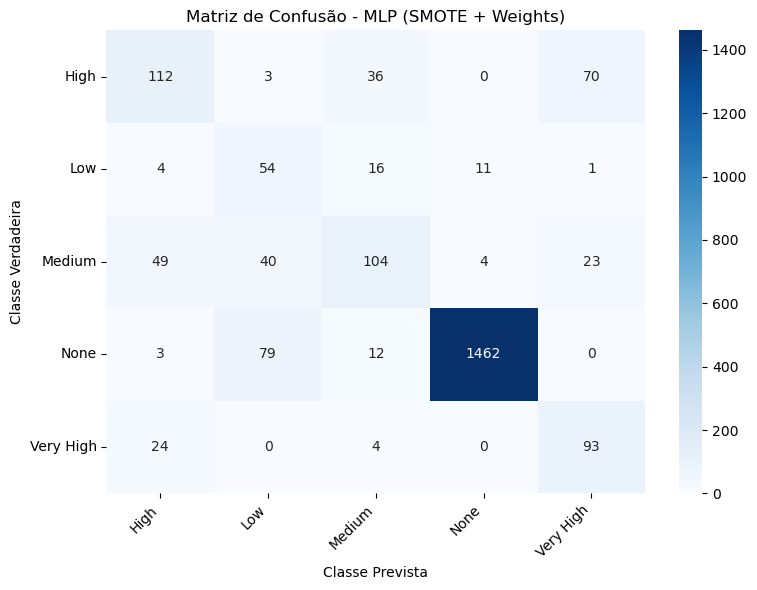

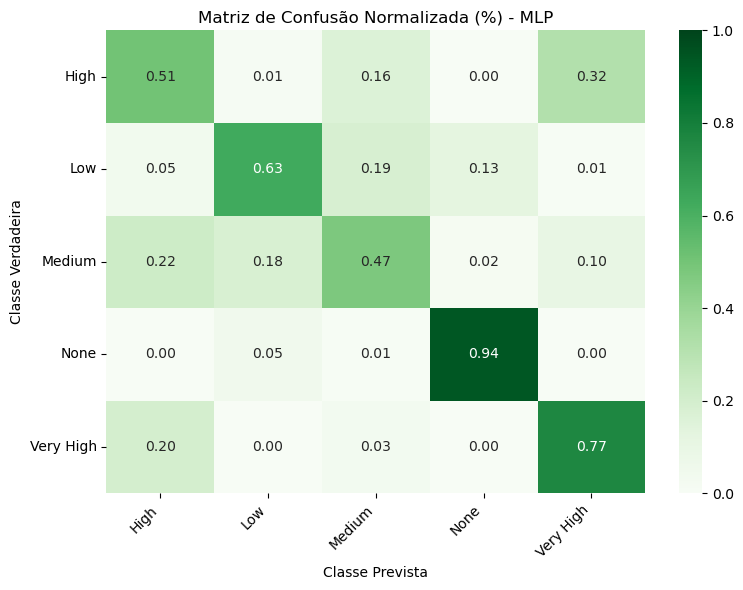

Guardado: matriz_confusao_keras.png | matriz_confusao_norm_keras.png


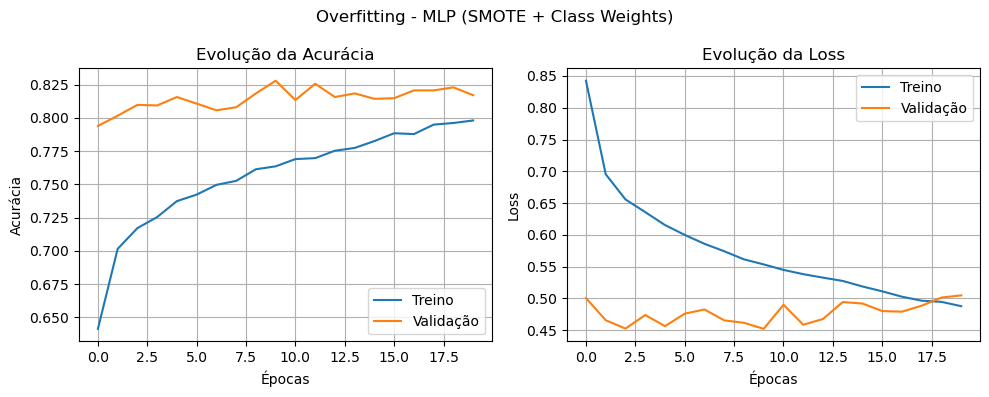

Guardado: grafico_overfitting_keras.png


In [27]:
# ==============================================================
# MLP (Keras) + SMOTE + Class Weights  → Treino, Avaliação e Gráficos
# ==============================================================

# -------------------- IMPORTS --------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

# -------------------- 1) CARREGAR E PREPARAR DADOS --------------------
energia_A = pd.read_csv('energia_202109-202112.csv', encoding='latin1')
energia_B = pd.read_csv('energia_202201-202212.csv', encoding='latin1')
meteo_A   = pd.read_csv('meteo_202109-202112.csv', encoding='latin1')
meteo_B   = pd.read_csv('meteo_202201-202212.csv', encoding='latin1')

energia = pd.concat([energia_A, energia_B], ignore_index=True)
meteo   = pd.concat([meteo_A, meteo_B], ignore_index=True)

# timestamps
energia['timestamp'] = pd.to_datetime(energia['Data']) + pd.to_timedelta(energia['Hora'], unit='h')
meteo['dt_iso_clean'] = meteo['dt_iso'].str.replace(' \+0000 UTC', '', regex=True)
meteo['timestamp'] = pd.to_datetime(meteo['dt_iso_clean'], format='%Y-%m-%d %H:%M:%S')

# merge
features_meteo = ['timestamp','temp','feels_like','temp_min','temp_max',
                  'pressure','humidity','wind_speed','rain_1h','clouds_all','weather_description']
df = pd.merge(energia, meteo[features_meteo], on='timestamp', how='left')

# missing values
numericas = ['temp','feels_like','temp_min','temp_max','pressure','humidity','wind_speed','clouds_all']
for col in numericas:
    df[col] = df[col].fillna(df[col].mean())
df['rain_1h'] = df['rain_1h'].fillna(0)
df['weather_description'] = df['weather_description'].fillna('missing')

# encoding da meteoro (simples: LabelEncoder → 1 coluna)
le_weather = LabelEncoder()
le_weather.fit(df['weather_description'])
df['weather_encoded'] = le_weather.transform(df['weather_description'])

# alvo
df['Injeção na rede (kWh)'] = df['Injeção na rede (kWh)'].fillna('None')
df_train = df.copy()
le_target = LabelEncoder()
df_train['y'] = le_target.fit_transform(df_train['Injeção na rede (kWh)'])
target_names = [str(c) for c in le_target.classes_]

# features finais (tabulares)
features = ['Normal (kWh)', 'Horário Económico (kWh)', 'Autoconsumo (kWh)'] \
           + numericas + ['rain_1h', 'clouds_all', 'weather_encoded']

X = df_train[features].values
y = df_train['y'].values

# -------------------- 2) SPLIT, SMOTE, SCALER --------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE só no treino
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# StandardScaler (ajusta no treino reamostrado e aplica ao val)
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_val       = scaler.transform(X_val)

# -------------------- 3) CLASS WEIGHTS --------------------
classes_unique = np.unique(y_train_res)
weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train_res)
class_weights_dict = {int(c): float(w) for c, w in zip(classes_unique, weights)}

# -------------------- 4) MODELO MLP (sparse) --------------------
num_classes = len(classes_unique)
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X_train_res.shape[1],)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(num_classes, activation='softmax')
])

earlystop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',   # rótulos inteiros → class_weight funciona
              metrics=['accuracy'])

# -------------------- 5) TREINO --------------------
history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[earlystop],
    verbose=2
)

# -------------------- 6) AVALIAÇÃO (VALIDAÇÃO) --------------------
y_val_pred_prob = model.predict(X_val)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

print("== Relatório detalhado KERAS (SMOTE + class weights) ==")
print(classification_report(y_val, y_val_pred, target_names=target_names))
print(confusion_matrix(y_val, y_val_pred))

# -------------------- 7) MATRIZES DE CONFUSÃO (com ficheiros) --------------------
cm = confusion_matrix(y_val, y_val_pred)
cm_norm = confusion_matrix(y_val, y_val_pred, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Classe Prevista"); plt.ylabel("Classe Verdadeira")
plt.title("Matriz de Confusão - MLP (SMOTE + Weights)")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig("matriz_confusao_keras.png", dpi=300); plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1,
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Classe Prevista"); plt.ylabel("Classe Verdadeira")
plt.title("Matriz de Confusão Normalizada (%) - MLP")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig("matriz_confusao_norm_keras.png", dpi=300); plt.show()

print("Guardado: matriz_confusao_keras.png | matriz_confusao_norm_keras.png")

# -------------------- 8) GRÁFICO DE OVERFITTING (accuracy e loss) --------------------
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Evolução da Acurácia'); plt.xlabel('Épocas'); plt.ylabel('Acurácia')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da Loss'); plt.xlabel('Épocas'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.suptitle("Overfitting - MLP (SMOTE + Class Weights)")
plt.tight_layout(); plt.savefig("grafico_overfitting_keras.png", dpi=300); plt.show()

print("Guardado: grafico_overfitting_keras.png")


In [ ]:
As class_weights são automáticas
As classes estão a ser confundidas, foi parado no tempo ideal, não há overfitting grave